### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score as f1_metric
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

### Load Dataset

In [2]:
df = pd.read_csv('./dataset/credit_card_fraud_dataset.csv')
print(df.shape)

(100000, 7)


### Start With the EDA (Exploratory Data Analysis)

**Get the type of columns in the dataset**

In [3]:
print(df.dtypes)

TransactionID        int64
TransactionDate     object
Amount             float64
MerchantID           int64
TransactionType     object
Location            object
IsFraud              int64
dtype: object


**Inspect the resume of the data:**

* It displays that the 1% of the data are frauds
* There are 1000 rows in each column
* Even distribution
* The values in the “amount” column lead us to suspect that the dataset is synthetic

In [4]:
print(df.describe())

       TransactionID         Amount     MerchantID        IsFraud
count  100000.000000  100000.000000  100000.000000  100000.000000
mean    50000.500000    2497.092666     501.676070       0.010000
std     28867.657797    1442.415999     288.715868       0.099499
min         1.000000       1.050000       1.000000       0.000000
25%     25000.750000    1247.955000     252.000000       0.000000
50%     50000.500000    2496.500000     503.000000       0.000000
75%     75000.250000    3743.592500     753.000000       0.000000
max    100000.000000    4999.770000    1000.000000       1.000000


**Detect null values in the dataset**

In [5]:
print(df.isna().sum())

TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64


**View the distribution in IsFraud**

IsFraud
0    99000
1     1000
Name: count, dtype: int64


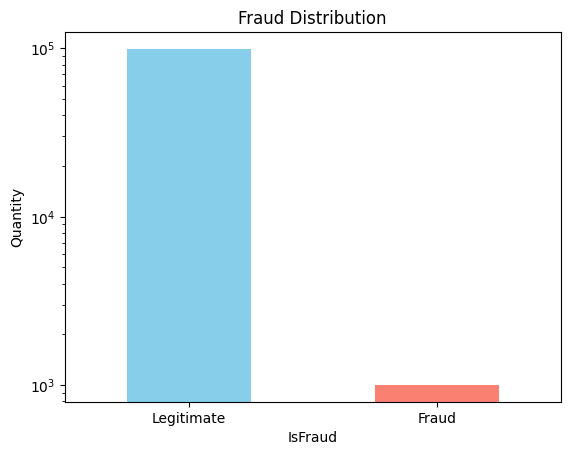

In [6]:
fraud_distribution = df['IsFraud'].value_counts()
print(fraud_distribution)
fraud_distribution.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Fraud Distribution')
plt.yscale('log')
plt.xlabel('IsFraud')
plt.ylabel('Quantity')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.show()

**View the Amount distribution**

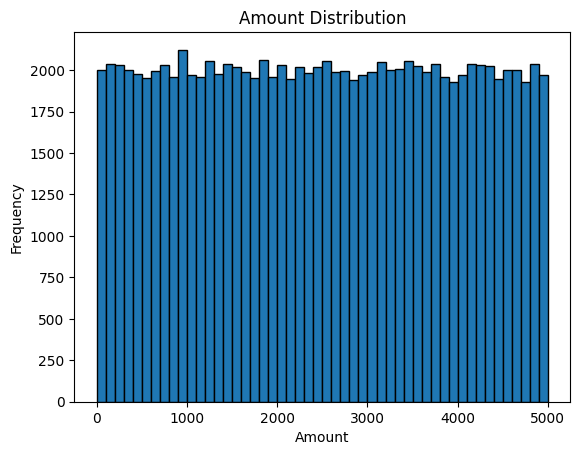

In [7]:
df['Amount'].plot(kind='hist', edgecolor='black', bins=50)
plt.title('Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

In [8]:
print(df['TransactionType'].value_counts())
print(df['Location'].value_counts())


TransactionType
refund      50131
purchase    49869
Name: count, dtype: int64
Location
Chicago         10193
San Diego       10111
Dallas          10076
San Antonio     10062
New York         9993
Houston          9991
Phoenix          9960
Los Angeles      9936
Philadelphia     9873
San Jose         9805
Name: count, dtype: int64


### Preprocessing

**First, drop the ids columns (TransactionID & MerchantID)**

In [9]:
df_clean = df.copy()

df_clean = df.drop(['TransactionID', 'MerchantID'], axis=1)
print(df_clean.columns)

Index(['TransactionDate', 'Amount', 'TransactionType', 'Location', 'IsFraud'], dtype='object')


**Extract extra features from TransactionDate**

In [10]:
df_clean['TransactionDate'] = pd.to_datetime(df_clean['TransactionDate'], errors='coerce')

In [11]:
df_clean['DayOfWeek'] = df_clean['TransactionDate'].dt.day_of_week
df_clean['IsWeekend'] = (df_clean['DayOfWeek'] >= 5).astype(int)
df_clean['Month'] = df_clean['TransactionDate'].dt.month

df_clean = df_clean.drop('TransactionDate', axis=1)

print(df_clean[['DayOfWeek', 'IsWeekend', 'Month']].head())

   DayOfWeek  IsWeekend  Month
0          2          0      4
1          1          0      3
2          0          0      1
3          5          1      4
4          4          0      7


**One-hot encoding with Location & TransactionType**

In [12]:
df_clean = (pd.get_dummies(df_clean, columns=['Location', 'TransactionType'], dtype=int))

In [13]:
print(df_clean.shape, df_clean.columns)

(100000, 17) Index(['Amount', 'IsFraud', 'DayOfWeek', 'IsWeekend', 'Month',
       'Location_Chicago', 'Location_Dallas', 'Location_Houston',
       'Location_Los Angeles', 'Location_New York', 'Location_Philadelphia',
       'Location_Phoenix', 'Location_San Antonio', 'Location_San Diego',
       'Location_San Jose', 'TransactionType_purchase',
       'TransactionType_refund'],
      dtype='object')


**Divide Target & Features**

In [14]:
y = df_clean['IsFraud']

X = df_clean.drop('IsFraud', axis=1)

### Separate Between Train & Test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

### Scale the Amount column with RobustScaler

In [16]:
scaler = RobustScaler()
scaler.fit(X_train[['Amount']])

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [17]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Amount']] = scaler.transform(X_train_scaled[['Amount']])
X_test_scaled[['Amount']] = scaler.transform(X_test_scaled[['Amount']])

### Logistic Regression

1. **Train model**
2. **Get the coefficients**
3. **Test the model**
4. **Get the metrics**

In [37]:
mlflow.set_experiment('credit-card-fraud-detection')

with mlflow.start_run(run_name='logistic-regression-balanced'):
    log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
    log_model.fit(X_train_scaled, y_train)
    mlflow.log_params({'max_iter': 1000, 'class_weight': 'balanced'})

    df_log_model = pd.DataFrame({
        'Variable': X_train_scaled.columns,
        'Weight': log_model.coef_[0],
    })

    df_log_model.to_csv('coeffs/coefficients.csv', index=False)
    mlflow.log_artifact('coeffs/coefficients.csv')

    y_pred = log_model.predict(X_test_scaled)
    f1 = (f1_metric(y_test, y_pred, pos_label=1))
    roc_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1])
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1)

    mlflow.log_metrics({'f1-score': f1, 'roc-auc': roc_auc, 'precision': precision, 'recall': recall})

In [38]:
print(df_log_model)

                    Variable    Weight
0                     Amount -0.009111
1                  DayOfWeek -0.001025
2                  IsWeekend  0.032619
3                      Month -0.010119
4           Location_Chicago  0.015657
5            Location_Dallas -0.018663
6           Location_Houston  0.076495
7       Location_Los Angeles  0.013961
8          Location_New York  0.080825
9      Location_Philadelphia -0.118861
10          Location_Phoenix -0.052162
11      Location_San Antonio  0.046468
12        Location_San Diego  0.105992
13         Location_San Jose -0.115215
14  TransactionType_purchase  0.003062
15    TransactionType_refund  0.031435


In [39]:
print('precision',precision)
print('recall', recall)
print('f1',f1)
print("ROC-AUC:", roc_auc)

precision 0.01193570122244682
recall 0.5511111111111111
f1 0.023365366497079328
ROC-AUC: 0.5242763309453574


### Random Forest

In [32]:
mlflow.set_experiment('credit-card-fraud-detection')

with mlflow.start_run(run_name='random-forest-regression-balanced'):
    random_forest_model = RandomForestClassifier(n_estimators=100, random_state=23, class_weight='balanced')
    random_forest_model.fit(X_train_scaled, y_train)
    mlflow.log_params({'n_estimators': 100, 'random_state': 23, 'class_weight':'balanced'})

    df_rf_model = pd.DataFrame({
        'Variable': X_train_scaled.columns,
        'Criterion': random_forest_model.criterion,
    })

    df_rf_model.to_csv('coeffs/coefficients_random.csv', index=False)
    mlflow.log_artifact('coeffs/coefficients_random.csv')

    y_pred = random_forest_model.predict(X_test_scaled)
    f1 = (f1_metric(y_test, y_pred, pos_label=1))
    roc_auc = roc_auc_score(y_test, random_forest_model.predict_proba(X_test_scaled)[:, 1])
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1)

    mlflow.log_metrics({'f1-score': f1, 'roc-auc': roc_auc, 'precision': precision, 'recall': recall})

In [33]:
print(df_rf_model)

                    Variable Criterion
0                     Amount      gini
1                  DayOfWeek      gini
2                  IsWeekend      gini
3                      Month      gini
4           Location_Chicago      gini
5            Location_Dallas      gini
6           Location_Houston      gini
7       Location_Los Angeles      gini
8          Location_New York      gini
9      Location_Philadelphia      gini
10          Location_Phoenix      gini
11      Location_San Antonio      gini
12        Location_San Diego      gini
13         Location_San Jose      gini
14  TransactionType_purchase      gini
15    TransactionType_refund      gini


In [34]:
print(precision)
print(recall)
print(f1)
print("ROC-AUC:", roc_auc)

0.0
0.0
0.0
ROC-AUC: 0.49271729175445983
